# Mount Google Drive


# ==================== CONFIGURATION ====================


In [85]:
### TITLE: Environment Setup & Library Imports
### OBJECTIVE: Import all necessary libraries for data manipulation, visualization, and system operations while suppressing unnecessary warnings.

import pandas as pd  # Data manipulation and analysis library
import numpy as np   # Numerical computing library for array operations
import matplotlib.pyplot as plt  # Core plotting library
import seaborn as sns  # Advanced statistical data visualization library based on matplotlib
import os              # Operating system interface for file path management
from datetime import datetime  # Library for date and time manipulations
import warnings      # Library to manage warning messages

# Suppress warning messages to keep the output clean and professional
warnings.filterwarnings('ignore')

In [86]:
### TITLE: Configuration Management Function
### OBJECTIVE: Define a centralized dictionary containing global parameters, thresholds, and file paths to ensure consistency throughout the pipeline.
from google.colab import drive  # Import the Colab-specific drive module

def get_config(project_folder_path=None):
    """Return configuration parameters for preprocessing"""
    # Check if a project folder path was provided; if not, default to local directory
    if project_folder_path is None:
        project_folder_path = '.'

    # Return a dictionary containing all global project settings
    return {
        'random_seed': 42,           # Seed for reproducibility in random sampling/operations
        # 'missing_rate': 0.05,        # Threshold for simulated missing data logic (if used)
        'outlier_percentile': 95,   # Percentile used for capping extreme wait time values
        'rush_hours': [12, 13, 18, 19, 20],  # Specific hours defined as high-traffic peak times
        # Path for the incoming raw dataset
        'input_file': os.path.join(project_folder_path, 'restaurant_pos_raw.csv'),
        # Path for the final cleaned dataset
        'output_file': os.path.join(project_folder_path, 'restaurant_pos_cleaned.csv'),
        # Path for a smaller subset of the cleaned data for previewing
        'sample_file': os.path.join(project_folder_path, 'restaurant_pos_sample.csv'),
        # Path for saving the EDA visual summary image
        'visualization_file': os.path.join(project_folder_path, 'restaurant_pos_eda.png')
    }

# ==================== LOAD DATA ====================


In [87]:
### TITLE: Raw Data Loading Engine
### OBJECTIVE: Read the raw CSV file into memory, handle basic error checking, and convert timestamp strings into datetime objects.

def load_raw_data(config):
    """Load raw CSV file generated by Project 1"""
    # Visual separator for the logging output
    print("\n" + "="*70)
    print("STEP 1: LOADING RAW DATA")
    print("="*70)

    # Extract the input file path from the configuration dictionary
    input_path = config['input_file']

    # Verify that the file actually exists on the drive before attempting to read
    if not os.path.exists(input_path):
        print(f"\n❌ ERROR: {input_path} not found!")
        return None

    # Use pandas to load the CSV data into a DataFrame structure
    df = pd.read_csv(input_path)

    # Convert the 'timestamp' column from string to proper datetime objects for time-based analysis
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    # Print summary statistics about the loaded file
    print(f"   ✅ Loaded {len(df):,} records from {input_path}")
    print(f"   Shape: {df.shape}")
    print(f"   Columns: {list(df.columns)}")

    # Return the loaded and partially formatted DataFrame
    return df

In [88]:
### TITLE: Initial Data Quality Inspection
### OBJECTIVE: Perform a diagnostic check on data types, identify missing value counts per column, and display descriptive statistics for numeric fields.

def initial_inspection(df):
    """Perform initial data inspection"""
    # Visual separator for the logging output
    print("\n" + "="*70)
    print("STEP 2: INITIAL DATA INSPECTION")
    print("="*70)

    # Output the data type of every column (numeric, object, datetime, etc.)
    print("\n--- Data Types ---")
    print(df.dtypes)

    # Calculate the sum of null/NaN values for each column to identify data gaps
    print("\n--- Missing Values ---")
    missing = df.isnull().sum()
    # Display columns with at least one missing value; otherwise, confirm data is complete
    print(missing[missing > 0] if (missing > 0).any() else "   No missing values")

    # Select only the numeric columns to avoid errors in statistical calculations
    print("\n--- Basic Statistics ---")
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    # Display mean, std, min, max, and quartiles for the numeric dataset subset
    print(df[numeric_cols].describe())

    # Return the dataframe unchanged (inspection only)
    return df

# ==================== DATA CLEANING FUNCTIONS ====================


In [89]:
### TITLE: Negative Value Removal
### OBJECTIVE: Identify and drop rows containing physically impossible negative numbers in operational metrics like queue length and guest count.

def remove_negative_values(df):
    """Remove rows with negative values in critical columns"""
    print("\n   Removing invalid values...")
    # Create a deep copy to avoid modifying the original dataframe in-place until intended
    df_clean = df.copy()

    # Initialize a counter to track how many rows are being removed
    negative_count = 0
    # Iterate through columns where negative values are logically impossible
    for col in ['queue_length', 'guests_served', 'table_count']:
        if col in df_clean.columns:
            # Count how many entries in this column are below zero
            neg = (df_clean[col] < 0).sum()
            if neg > 0:
                # Filter the dataframe to keep only values zero or greater
                df_clean = df_clean[df_clean[col] >= 0]
                negative_count += neg

    # Report the results of the cleaning step
    if negative_count > 0:
        print(f"      Removed {negative_count} rows with negative values")
    else:
        print(f"      No negative values found")

    # Return the filtered dataframe
    return df_clean

In [90]:
### TITLE: Group-Based Wait Time Imputation
### OBJECTIVE: Fill missing wait time values using the median of the specific cuisine and traffic period to maintain statistical accuracy.

def impute_missing_wait_times(df):
    """Impute missing wait times using grouped median"""
    print("\n   Imputing missing wait times...")
    # Calculate count of missing wait times before imputation
    initial_missing = df['avg_wait_minutes'].isnull().sum()

    if initial_missing > 0:
        # Create a temporary grouping key combining cuisine and rush hour status (e.g., 'Italian_True')
        df['impute_group'] = df['cuisine_type'].fillna('Unknown') + '_' + df['is_rush_hour'].astype(str)
        # Calculate the median for each group and apply it to missing cells within that group
        group_medians = df.groupby('impute_group')['avg_wait_minutes'].transform('median')
        df['avg_wait_minutes'] = df['avg_wait_minutes'].fillna(group_medians)
        # Clean up by removing the temporary helper column
        df.drop('impute_group', axis=1, inplace=True)

        # Safety check: if groups were empty, fill any remaining NAs with the overall dataset median
        if df['avg_wait_minutes'].isnull().sum() > 0:
            global_median = df['avg_wait_minutes'].median()
            df['avg_wait_minutes'] = df['avg_wait_minutes'].fillna(global_median)

        print(f"      Imputed {initial_missing} missing values")
    else:
        print(f"      No missing values to impute")

    # Return the dataframe with completed wait time columns
    return df

In [91]:
### TITLE: Outlier Detection and Capping (Winsorization)
### OBJECTIVE: Use the Interquartile Range (IQR) method to identify extreme outliers and cap them at a specific percentile to reduce noise.

def detect_and_cap_outliers(df, config):
    """Detect outliers using IQR method and cap them"""
    print("\n   Detecting and capping outliers...")

    # Calculate the first and third quartiles
    Q1 = df['avg_wait_minutes'].quantile(0.25)
    Q3 = df['avg_wait_minutes'].quantile(0.75)
    # Determine the Interquartile Range
    IQR = Q3 - Q1
    # Calculate bounds for statistical outliers
    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR

    # Count records falling outside these statistical bounds
    outliers_upper = (df['avg_wait_minutes'] > upper_bound).sum()
    outliers_lower = (df['avg_wait_minutes'] < lower_bound).sum()

    # Print detection results to console
    print(f"      Upper bound: {upper_bound:.1f} min")
    print(f"      Lower bound: {lower_bound:.1f} min")
    print(f"      Outliers above: {outliers_upper}")
    print(f"      Outliers below: {outliers_lower}")

    # Determine the value at the defined outlier percentile (e.g., 95th)
    cap_value = df['avg_wait_minutes'].quantile(config['outlier_percentile'] / 100)
    # Create a new column where values higher than the cap are reduced to the cap value
    df['avg_wait_minutes_capped'] = df['avg_wait_minutes'].clip(upper=cap_value)

    print(f"      Capped at {cap_value:.1f} minutes ({config['outlier_percentile']}th percentile)")

    # Return the dataframe with the new capped column
    return df

In [92]:
### TITLE: Final Missing Value Mitigation
### OBJECTIVE: Apply logical default values to any remaining missing fields in non-critical columns like weather or average check amounts.

def fill_remaining_nas(df):
    """Fill any remaining NA values with defaults"""
    print("\n   Filling remaining NAs...")

    # Define a dictionary of sensible default values for various restaurant metrics
    default_values = {
        'temperature_c': 18,     # Assume mild weather if missing
        'precipitation_mm': 0,   # Assume no rain if missing
        'table_count': 30,       # Average restaurant size
        'avg_check_usd': 35,     # Average spending amount
        'party_size': 2          # Standard dining pair
    }

    # Loop through the defaults and apply them only to existing columns with missing data
    for col, default in default_values.items():
        if col in df.columns and df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(default)

    # Confirm count of all remaining missing values across the whole dataframe
    print(f"      Final missing count: {df.isnull().sum().sum()}")

    return df

In [93]:
### TITLE: Integrated Cleaning Pipeline
### OBJECTIVE: Orchestrate the sequence of all cleaning functions (negative removal, imputation, capping, and defaults) into a single executable step.

def clean_data(df, config):
    """Main data cleaning pipeline"""
    print("\n" + "="*70)
    print("STEP 3: DATA CLEANING")
    print("="*70)

    # Copy the dataframe to ensure the raw input remains untouched for comparison
    df_clean = df.copy()

    # Execute step 1: Eliminate negative numerical errors
    df_clean = remove_negative_values(df_clean)

    # Execute step 2: Handle missing target variable data (wait times)
    df_clean = impute_missing_wait_times(df_clean)

    # Execute step 3: Limit the influence of extreme data spikes
    df_clean = detect_and_cap_outliers(df_clean, config)

    # Execute step 4: Final cleanup of secondary categorical/numeric columns
    df_clean = fill_remaining_nas(df_clean)

    # Print final validation metrics for the cleaned set
    print(f"\n   ✅ Final cleaned shape: {df_clean.shape}")
    print(f"   ✅ No missing values: {df_clean.isnull().sum().sum() == 0}")

    return df_clean

# =============== FEATURE ENGINEERING FUNCTIONS ===============


In [94]:
### TITLE: Cyclical Time Feature Engineering
### OBJECTIVE: Convert linear time features (hours/days) into sine and cosine transformations to preserve the cyclical nature of time for machine learning.

def create_time_features(df):
    """Create cyclical time-based features"""
    print("\n   Creating time features...")

    # Ensure the timestamp column is in datetime format
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    # Map 'hour' (0-23) to a circle and calculate sin/cos coordinates
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    # Map 'day_of_week' (0-6) to a circle and calculate sin/cos coordinates
    df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

    # Extract the calendar quarter from the timestamp
    df['quarter'] = df['timestamp'].dt.quarter

    return df

In [95]:
### TITLE: Operational Feature Engineering
### OBJECTIVE: Derive new metrics that represent restaurant performance, efficiency, and occupancy ratios.

def create_operational_features(df):
    """Create operational efficiency metrics"""
    print("\n   Creating operational features...")

    # Calculate how crowded the restaurant is (queue length per available table)
    df['occupancy_rate'] = df['queue_length'] / df['table_count'].clip(lower=1)

    # Calculate how many guests are served per table (throughput)
    df['turnover_rate'] = df['guests_served'] / df['table_count'].clip(lower=1)

    # Calculate average spending efficiency (total revenue divided by total guests)
    df['revenue_per_guest'] = df['revenue_usd'] / df['guests_served'].clip(lower=1)

    # Create a specific ratio for queue density
    df['queue_to_seats_ratio'] = df['queue_length'] / df['table_count'].clip(lower=1)

    # Calculate the average number of people in a single party/group
    df['guests_per_party'] = df['guests_served'] / df['party_size'].clip(lower=1)

    # Limit the queue ratio to a maximum of 3 to avoid extreme outliers in ratios
    df['queue_to_seats_ratio'] = df['queue_to_seats_ratio'].clip(upper=3)

    return df

In [96]:
### TITLE: Categorical Feature Binning
### OBJECTIVE: Group continuous numerical values (wait times, hours) into discrete categories for easier pattern recognition and visualization.

def create_categorical_features(df):
    """Create categorical variables for analysis"""
    print("\n   Creating categorical features...")

    # Divide wait times into descriptive buckets (e.g., 'very_fast' for 0-10 mins)
    df['wait_category'] = pd.cut(
        df['avg_wait_minutes_capped'],
        bins=[0, 10, 20, 30, 60, 120],
        labels=['very_fast', 'fast', 'moderate', 'long', 'very_long']
    )

    # Map 24-hour integers to specific dining periods (Morning, Lunch, Afternoon, Dinner, Evening)
    df['period'] = df['hour'].apply(
        lambda x: 'morning' if x < 12 else ('lunch_rush' if x in [12,13] else
                  ('afternoon' if x < 17 else ('dinner_rush' if x in [18,19,20] else 'evening')))
    )

    # Transform the 0/1 weekend indicator into human-readable text labels
    df['day_type'] = df['is_weekend'].map({0: 'weekday', 1: 'weekend'})

    return df

In [97]:
### TITLE: Feature Engineering Orchestrator
### OBJECTIVE: Execute the full suite of feature creation functions to transform the cleaned data into a modeling-ready format.

def engineer_features(df):
    """Main feature engineering pipeline"""
    print("\n" + "="*70)
    print("STEP 4: FEATURE ENGINEERING")
    print("="*70)

    # Store the count of original columns to calculate how many new ones were added
    original_cols = df.shape[1]

    # Run the time, operational, and categorical transformations
    df = create_time_features(df)
    df = create_operational_features(df)
    df = create_categorical_features(df)

    # Display the net gain in features to the user
    new_features = df.shape[1] - original_cols
    print(f"\n   ✅ Added {new_features} new features")
    print(f"   Total features: {df.shape[1]}")

    return df

# ==================== VISUALIZATION FUNCTIONS ====================


In [98]:
### TITLE: Wait Time Distribution Plotter
### OBJECTIVE: Visualize the frequency of different wait times using a histogram with central tendency indicators (mean/median).

def create_wait_distribution_plot(df, ax):
    """Plot wait time distribution"""
    # Create a histogram of capped wait times with 30 bins for granularity
    ax.hist(df['avg_wait_minutes_capped'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    # Add a vertical dashed line at the median value
    ax.axvline(df['avg_wait_minutes_capped'].median(), color='red', linestyle='--', label=f'Median: {df["avg_wait_minutes_capped"].median():.1f}')
    # Add a vertical dashed line at the mean value
    ax.axvline(df['avg_wait_minutes_capped'].mean(), color='orange', linestyle='--', label=f'Mean: {df["avg_wait_minutes_capped"].mean():.1f}')
    # Configure chart title and labels
    ax.set_title('Wait Time Distribution', fontsize=12)
    ax.set_xlabel('Minutes')
    ax.set_ylabel('Frequency')
    # Display the legend to identify mean vs median
    ax.legend()

In [99]:
### TITLE: Cuisine Performance Comparison Plotter
### OBJECTIVE: Generate a horizontal bar chart comparing the average wait times across different types of cuisine.

def create_cuisine_comparison_plot(df, ax):
    """Plot wait time by cuisine type"""
    # Calculate mean wait time grouped by cuisine and sort from lowest to highest
    cuisine_wait = df.groupby('cuisine_type')['avg_wait_minutes_capped'].mean().sort_values()
    # Generate a color gradient (colormap) based on the number of cuisines
    colors_cmap = plt.cm.get_cmap('YlGnBu', len(cuisine_wait))
    # Create horizontal bars with the generated colors
    cuisine_wait.plot(kind='barh', ax=ax, color=colors_cmap(np.linspace(0, 1, len(cuisine_wait))))
    # Set title and axis label
    ax.set_title('Average Wait Time by Cuisine', fontsize=12)
    ax.set_xlabel('Minutes')

In [100]:
### TITLE: Hourly Traffic Pattern Plotter
### OBJECTIVE: Display the fluctuation of wait times over 24 hours, highlighting peak rush periods and statistical variance.

def create_hourly_pattern_plot(df, ax, config):
    """Plot hourly wait time pattern"""
    # Calculate both mean and standard deviation for each hour
    hourly_wait = df.groupby('hour')['avg_wait_minutes_capped'].agg(['mean', 'std'])
    # Plot the average wait time line with circular markers
    ax.plot(hourly_wait.index, hourly_wait['mean'], marker='o', linewidth=2, color='teal', label='Mean')
    # Shade the area representing +/- 1 standard deviation for confidence visualization
    ax.fill_between(hourly_wait.index, hourly_wait['mean'] - hourly_wait['std'], hourly_wait['mean'] + hourly_wait['std'], alpha=0.2, color='teal', label='±1 Std')

    # Draw vertical red dashed lines for hours designated as 'rush hours' in config
    for rush_hour in config['rush_hours']:
        ax.axvline(x=rush_hour, color='red', linestyle='--', alpha=0.5, linewidth=1)

    # Set titles and axis labels
    ax.set_title('Wait Time by Hour (Rush hours marked in red)', fontsize=12)
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Wait Time (minutes)')
    ax.legend()

In [101]:
### TITLE: Queue-to-Wait Relationship Scatter Plot
### OBJECTIVE: Examine the correlation between physical queue length and resulting wait times using a scatter plot and a linear trend line.

def create_relationship_plots(df, ax):
    """Create relationship scatter plots"""
    # Create a semi-transparent scatter plot to handle point overlap
    ax.scatter(df['queue_length'], df['avg_wait_minutes_capped'], alpha=0.3, s=10, c='green')

    # Calculate a linear regression (trend line) through the scatter data
    z = np.polyfit(df['queue_length'], df['avg_wait_minutes_capped'], 1)
    p = np.poly1d(z)
    # Generate a range of x-values for plotting the smooth trend line
    x_trend = np.linspace(df['queue_length'].min(), df['queue_length'].max(), 100)
    # Plot the trend line in red with the slope displayed in the legend
    ax.plot(x_trend, p(x_trend), "r--", alpha=0.8, label=f'Trend (slope={z[0]:.2f})')

    # Set titles and axis labels
    ax.set_title('Queue Length vs Wait Time', fontsize=12)
    ax.set_xlabel('Queue Length')
    ax.set_ylabel('Wait Time (minutes)')
    ax.legend()

In [102]:
### TITLE: Weekend vs Weekday Comparison Plotter
### OBJECTIVE: Use a bar chart to show the difference in average wait times between weekdays and weekends, including error bars for variance.

def create_weekend_comparison_plot(df, ax):
    """Plot weekend vs weekday comparison"""
    # Group data by weekend status and get mean/std for wait times
    weekend_stats = df.groupby('is_weekend')['avg_wait_minutes_capped'].agg(['mean', 'std'])
    x_pos = [0, 1]  # Define x-axis positions for the two bars
    # Create the bars with distinct colors and standard deviation error bars
    ax.bar(x_pos, weekend_stats['mean'], yerr=weekend_stats['std'], capsize=5, color=['#3498db', '#e74c3c'], alpha=0.7)
    # Map the numeric labels (0/1) to descriptive text
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['Weekday', 'Weekend'])
    ax.set_title('Wait Time: Weekend vs Weekday', fontsize=12)
    ax.set_ylabel('Wait Time (minutes)')

In [103]:
### TITLE: Multi-Feature Correlation Heatmap
### OBJECTIVE: Generate a color-coded matrix showing how all major numeric features correlate with each other, focusing on the target variable.

def create_correlation_heatmap(df, ax):
    """Create correlation heatmap"""
    # Select only the numeric columns for correlation calculation
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    corr_matrix = df[numeric_cols].corr()

    # Define a list of high-impact features for a focused heatmap
    relevant_cols = ['avg_wait_minutes_capped', 'guests_served', 'queue_length', 'table_count', 'hour', 'day_of_week', 'revenue_usd', 'party_size', 'occupancy_rate']
    # Filter list to ensure selected columns actually exist in the dataframe
    existing_cols = [c for c in relevant_cols if c in corr_matrix.columns]
    corr_subset = corr_matrix.loc[existing_cols, existing_cols]

    # Draw the heatmap with annotations (numeric values) and a diverging color map
    sns.heatmap(corr_subset, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True, ax=ax, cbar_kws={'shrink': 0.8})
    ax.set_title('Feature Correlations', fontsize=12)

In [104]:
### TITLE: Exploratory Data Analysis (EDA) Visualization Suite
### OBJECTIVE: Generate individual, high-resolution plots for each key metric with clear spacing between figures.

def create_visualizations(df, config):
    """Create all visualizations as separate plots with added spacing"""
    print("\n" + "="*70)
    print("STEP 5: CREATING VISUALIZATIONS")
    print("="*70)

    # 1. Wait Time Distribution
    plt.figure(figsize=(10, 6))
    create_wait_distribution_plot(df, plt.gca())
    plt.tight_layout(pad=3.0)
    plt.show()
    print("\n") # Textual separator for notebook flow

    # 2. Cuisine Comparison
    plt.figure(figsize=(10, 8))
    create_cuisine_comparison_plot(df, plt.gca())
    plt.tight_layout(pad=3.0)
    plt.show()
    print("\n")

    # 3. Hourly Patterns
    plt.figure(figsize=(12, 6))
    create_hourly_pattern_plot(df, plt.gca(), config)
    plt.tight_layout(pad=3.0)
    plt.show()
    print("\n")

    # 4. Queue vs Wait Relationship
    plt.figure(figsize=(10, 6))
    create_relationship_plots(df, plt.gca())
    plt.tight_layout(pad=3.0)
    plt.show()
    print("\n")

    # 5. Weekend vs Weekday
    plt.figure(figsize=(8, 6))
    create_weekend_comparison_plot(df, plt.gca())
    plt.tight_layout(pad=3.0)
    plt.show()
    print("\n")

    # 6. Correlation Heatmap
    plt.figure(figsize=(12, 10))
    create_correlation_heatmap(df, plt.gca())
    plt.tight_layout(pad=3.0)

    # Save the last active figure to file
    plt.savefig(config['visualization_file'], dpi=150, bbox_inches='tight')
    plt.show()

    print(f"   ✅ Visualizations generated and summary saved to {config['visualization_file']}")

    return True

# ==================== EXPORT FUNCTIONS ====================


In [105]:
### TITLE: Data Export Engine
### OBJECTIVE: Save the final processed dataframe and a smaller sample to CSV files for use in modeling and quick review.

def export_cleaned_data(df, config):
    """Export cleaned data to CSV files"""
    print("\n" + "="*70)
    print("STEP 6: EXPORTING CLEANED DATA")
    print("="*70)

    # Save the full processed dataset without row indices
    df.to_csv(config['output_file'], index=False)
    print(f"   ✅ Full dataset: {config['output_file']}")
    print(f"      Shape: {df.shape}")

    # Generate a random sample of 1000 rows (or fewer if dataset is small)
    df_sample = df.sample(min(1000, len(df)), random_state=config['random_seed'])
    # Save the sample dataset for quick inspections
    df_sample.to_csv(config['sample_file'], index=False)
    print(f"   ✅ Sample dataset: {config['sample_file']}")
    print(f"      Shape: {df_sample.shape}")

    return True

In [106]:
### TITLE: Executive Summary Report Generator
### OBJECTIVE: Print a formatted text summary of the dataset's final state, target variable stats, and key operational insights.

def generate_summary_report(df, config):
    """Generate and print final summary report"""
    print("\n" + "="*70)
    print("FINAL SUMMARY REPORT")
    print("="*70)

    # Isolate numeric columns for statistical summaries
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    # Print high-level counts and overview metrics
    print(f"""
📊 Dataset Overview:
   • Input file: {config['input_file']}
   • Output file: {config['output_file']}
   • Total records: {len(df):,}
   • Features: {df.shape[1]}
   • Restaurant count: {df['restaurant_id'].nunique()}
   • Cuisine types: {df['cuisine_type'].nunique()}
   • Boroughs: {df['borough'].nunique() if 'borough' in df.columns else 'N/A'}

📈 Target Variable (Wait Time - Capped):
   • Mean: {df['avg_wait_minutes_capped'].mean():.1f} minutes
   • Median: {df['avg_wait_minutes_capped'].median():.1f} minutes
   • Std Dev: {df['avg_wait_minutes_capped'].std():.1f}
   • Min: {df['avg_wait_minutes_capped'].min():.0f}
   • Max: {df['avg_wait_minutes_capped'].max():.0f}

📊 Hourly Patterns:
   • Peak wait time hour: {df.groupby('hour')['avg_wait_minutes_capped'].mean().idxmax()}:00
   • Peak wait time: {df.groupby('hour')['avg_wait_minutes_capped'].mean().max():.1f} min
   • Lowest wait time hour: {df.groupby('hour')['avg_wait_minutes_capped'].mean().idxmin()}:00
   • Lowest wait time: {df.groupby('hour')['avg_wait_minutes_capped'].mean().min():.1f} min

🍽️ By Cuisine (Top 3 highest wait):
""")

    # Identify and display the three cuisines with the highest average wait times
    cuisine_rank = df.groupby('cuisine_type')['avg_wait_minutes_capped'].mean().sort_values(ascending=False).head(3)
    for cuisine, wait in cuisine_rank.items():
        print(f"   • {cuisine}: {wait:.1f} minutes")

    # Print final validation summary and file location reminder
    print(f"""
✅ Data Quality:
   • Missing values: {df.isnull().sum().sum()}
   • Outliers capped at {config['outlier_percentile']}th percentile

📁 Output Files:
   1. {config['output_file']} - Full cleaned dataset
   2. {config['sample_file']} - Sample (1000 rows)
   3. {config['visualization_file']} - EDA plots
""")

# ==================== MAIN FUNCTION ====================


In [107]:
### TITLE: Preprocessor Introduction Header
### OBJECTIVE: Display a summary of the script's capabilities and current pipeline phase when executed.

# Main preprocessing pipeline descriptive block
print("\n" + "="*70)
print("🍽️ RESTAURANT POS DATA PREPROCESSOR")
print("="*70)
print("\n This script loads raw CSV and performs:")
print("   - Data cleaning (missing values, outliers)")
print("   - Feature engineering")
print("   - Visualization generation")
print("   - Export cleaned data\n")


🍽️ RESTAURANT POS DATA PREPROCESSOR

 This script loads raw CSV and performs:
   - Data cleaning (missing values, outliers)
   - Feature engineering
   - Visualization generation
   - Export cleaned data



In [108]:
### TITLE: Pipeline Configuration Initialization
### OBJECTIVE: Initialize the global config dictionary and set the random seed for all subsequent operations to ensure reproducibility.

# Access the global project folder variable established in previous cells
# Initialize project_folder if it hasn't been defined elsewhere
project_folder = "/content/drive/MyDrive/Colab Notebooks/restaurant_smart_wait" # Assign a default value for the project folder

# Load the configuration settings based on the project folder path
config = get_config(project_folder_path=project_folder)

# Set the random seed for numpy to ensure random operations (like sampling) produce consistent results
np.random.seed(config['random_seed'])

In [109]:
### TITLE: Pipeline Execution - Data Loading
### OBJECTIVE: Call the loading function to bring the raw data into the notebook environment.

# Trigger the raw data loading function and store the result in df_raw
df_raw = load_raw_data(config)


STEP 1: LOADING RAW DATA
   ✅ Loaded 18,688 records from /content/drive/MyDrive/Colab Notebooks/restaurant_smart_wait/restaurant_pos_raw.csv
   Shape: (18688, 17)
   Columns: ['restaurant_id', 'restaurant_name', 'cuisine_type', 'borough', 'timestamp', 'date', 'hour', 'day_of_week', 'is_weekend', 'is_rush_hour', 'guests_served', 'queue_length', 'table_count', 'avg_wait_minutes', 'revenue_usd', 'avg_check_usd', 'party_size']


In [110]:
### TITLE: Pipeline Execution - Data Inspection
### OBJECTIVE: Execute the inspection function to review the health of the newly loaded raw data.

# Analyze the raw dataframe for types, nulls, and statistical distributions
df_raw = initial_inspection(df_raw)


STEP 2: INITIAL DATA INSPECTION

--- Data Types ---
restaurant_id               object
restaurant_name             object
cuisine_type                object
borough                     object
timestamp           datetime64[ns]
date                        object
hour                         int64
day_of_week                  int64
is_weekend                   int64
is_rush_hour                 int64
guests_served              float64
queue_length                 int64
table_count                  int64
avg_wait_minutes           float64
revenue_usd                float64
avg_check_usd                int64
party_size                 float64
dtype: object

--- Missing Values ---
cuisine_type         868
borough              823
guests_served        883
avg_wait_minutes    1057
revenue_usd          871
party_size           932
dtype: int64

--- Basic Statistics ---
               hour   day_of_week    is_weekend  is_rush_hour  guests_served  \
count  18688.000000  18688.000000  18688.0000

In [111]:
### TITLE: Pipeline Execution - Data Cleaning
### OBJECTIVE: Run the full cleaning logic to produce a sanitized dataset (df_cleaned).

# Apply all cleaning steps (null imputation, capping, and error removal) to the raw data
df_cleaned = clean_data(df_raw, config)


STEP 3: DATA CLEANING

   Removing invalid values...
      Removed 216 rows with negative values

   Imputing missing wait times...
      Imputed 998 missing values

   Detecting and capping outliers...
      Upper bound: 30.5 min
      Lower bound: -13.5 min
      Outliers above: 298
      Outliers below: 0
      Capped at 25.0 minutes (95th percentile)

   Filling remaining NAs...
      Final missing count: 2393

   ✅ Final cleaned shape: (17589, 18)
   ✅ No missing values: False


In [112]:
### TITLE: Pipeline Execution - Feature Engineering
### OBJECTIVE: Enrich the cleaned dataset with the new calculated metrics and cyclical time features.

# Apply the transformation functions to the cleaned dataframe to create new insights
df_cleaned = engineer_features(df_cleaned)


STEP 4: FEATURE ENGINEERING

   Creating time features...

   Creating operational features...

   Creating categorical features...

   ✅ Added 13 new features
   Total features: 31



STEP 5: CREATING VISUALIZATIONS


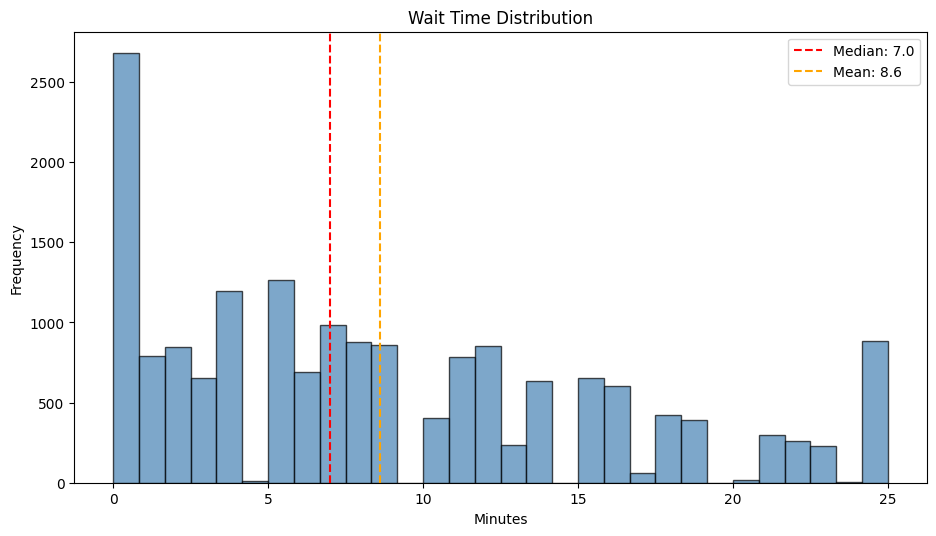

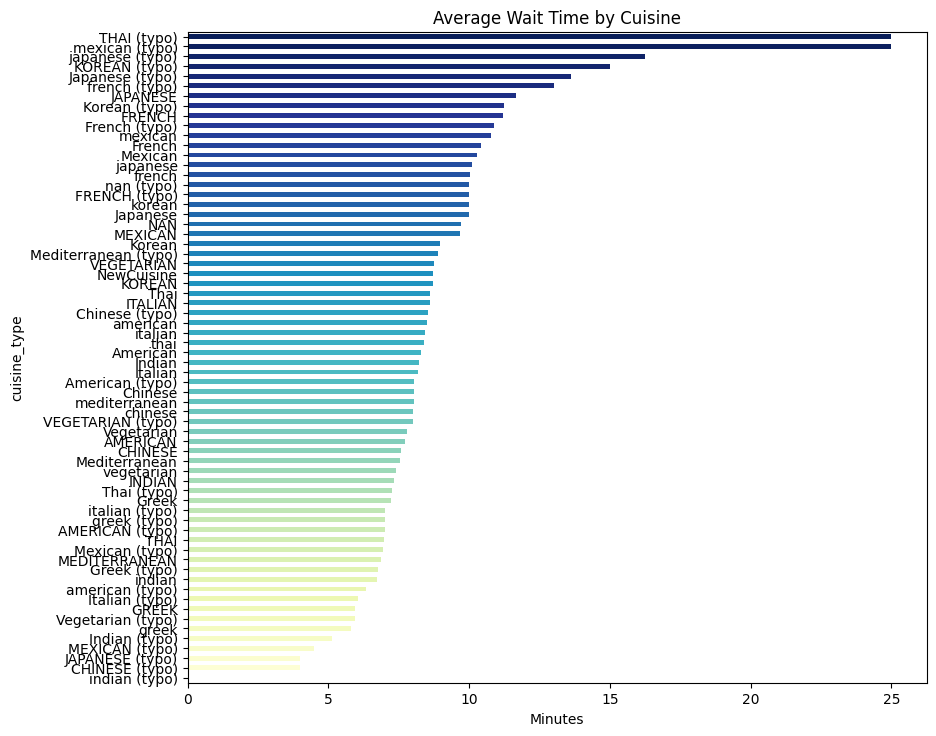

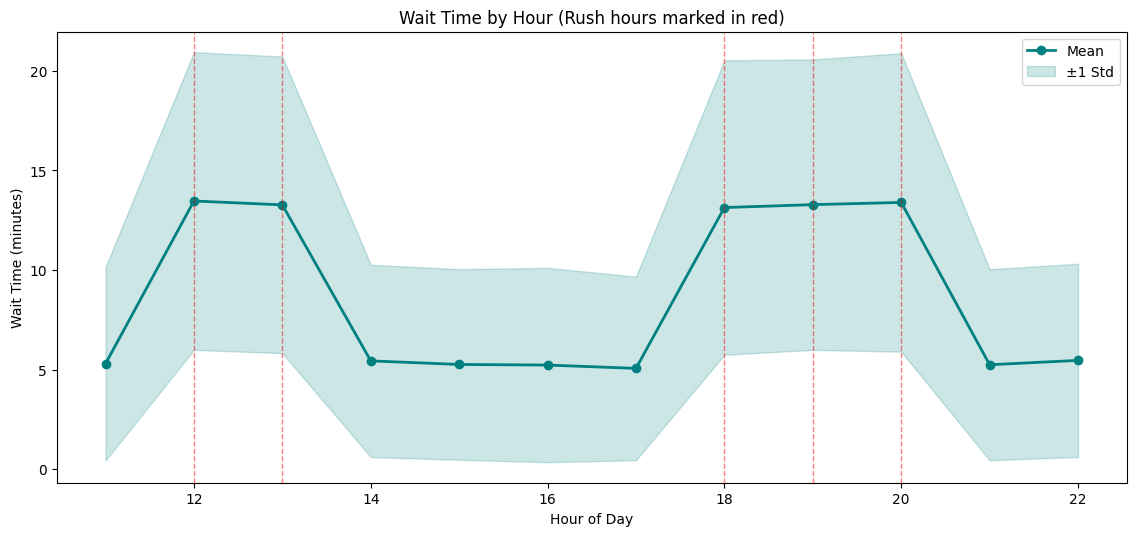

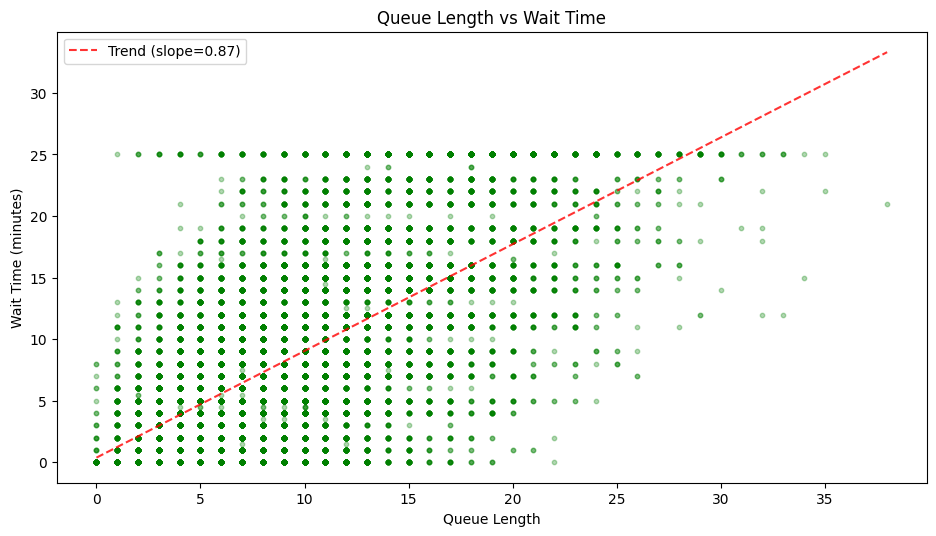

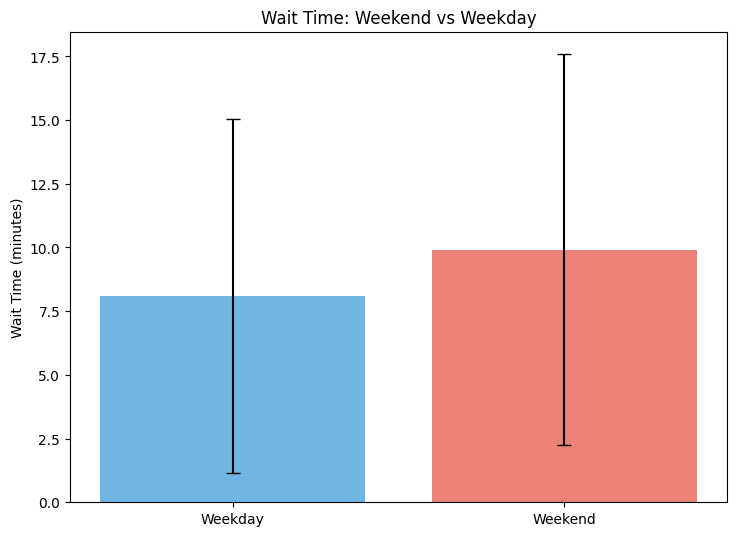

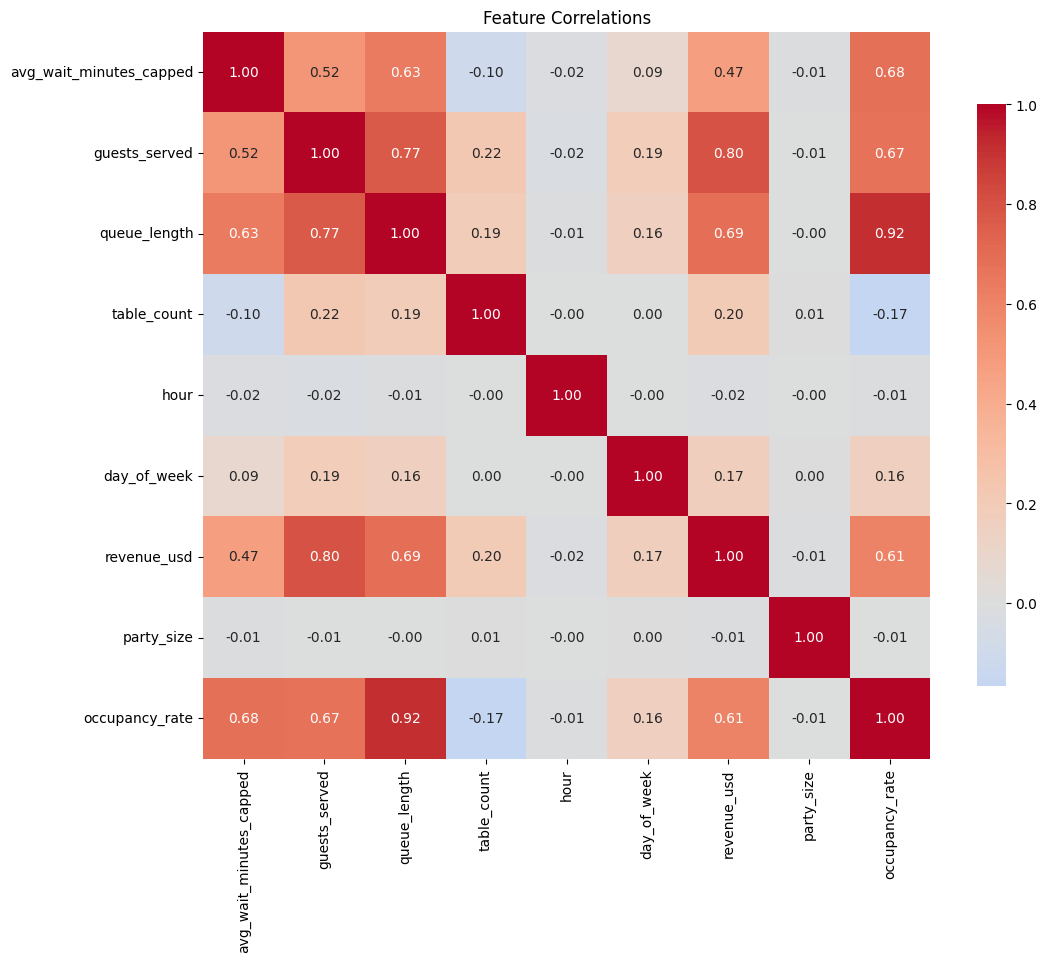

   ✅ Visualizations generated and summary saved to /content/drive/MyDrive/Colab Notebooks/restaurant_smart_wait/restaurant_pos_eda.png


True

In [113]:
### TITLE: Pipeline Execution - Data Visualization
### OBJECTIVE: Generate the visual dashboard from the processed data.

# Call the visualization suite to create and save charts to the drive
create_visualizations(df_cleaned, config)

In [114]:
### TITLE: Pipeline Execution - Data Export
### OBJECTIVE: Save the final state of the dataframe to persistent storage.

# Save both the full and sample cleaned CSV files for future model development
export_cleaned_data(df_cleaned, config)


STEP 6: EXPORTING CLEANED DATA
   ✅ Full dataset: /content/drive/MyDrive/Colab Notebooks/restaurant_smart_wait/restaurant_pos_cleaned.csv
      Shape: (17589, 31)
   ✅ Sample dataset: /content/drive/MyDrive/Colab Notebooks/restaurant_smart_wait/restaurant_pos_sample.csv
      Shape: (1000, 31)


True

In [115]:
### TITLE: Pipeline Execution - Summary Reporting
### OBJECTIVE: Print the final comprehensive health report of the processed data.

# Generate the terminal output report with all final dataset statistics
generate_summary_report(df_cleaned, config)


FINAL SUMMARY REPORT

📊 Dataset Overview:
   • Input file: /content/drive/MyDrive/Colab Notebooks/restaurant_smart_wait/restaurant_pos_raw.csv
   • Output file: /content/drive/MyDrive/Colab Notebooks/restaurant_smart_wait/restaurant_pos_cleaned.csv
   • Total records: 17,589
   • Features: 31
   • Restaurant count: 12
   • Cuisine types: 66
   • Boroughs: 12

📈 Target Variable (Wait Time - Capped):
   • Mean: 8.6 minutes
   • Median: 7.0 minutes
   • Std Dev: 7.2
   • Min: 0
   • Max: 25

📊 Hourly Patterns:
   • Peak wait time hour: 12:00
   • Peak wait time: 13.5 min
   • Lowest wait time hour: 17:00
   • Lowest wait time: 5.1 min

🍽️ By Cuisine (Top 3 highest wait):

   • THAI (typo): 25.0 minutes
   • mexican (typo): 25.0 minutes
   • japanese (typo): 16.2 minutes

✅ Data Quality:
   • Missing values: 5880
   • Outliers capped at 95th percentile

📁 Output Files:
   1. /content/drive/MyDrive/Colab Notebooks/restaurant_smart_wait/restaurant_pos_cleaned.csv - Full cleaned dataset
   2